# Credit Card Fraud Detection - Advanced
**Level 2 - Project 5**

**Objective:** Advanced fraud detection using Anomaly Detection (Isolation Forest, LOF) + Autoencoder.



In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn imbalanced-learn xgboost --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from xgboost import XGBClassifier
from sklearn.metrics import *
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import warnings; warnings.filterwarnings('ignore')
print('✅ Libraries imported!')

✅ Libraries imported!


## Load Dataset

In [3]:
from google.colab import files
import io
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
cd=df['Class'].value_counts()
print(f'Shape: {df.shape}')
print(f'Fraud: {cd[1]} ({cd[1]/len(df)*100:.3f}%), Ratio: 1:{cd[0]//cd[1]}')

Saving creditcard.csv to creditcard.csv
Shape: (284807, 31)
Fraud: 492 (0.173%), Ratio: 1:577


## Advanced EDA

In [4]:
from scipy import stats
fraud=df[df['Class']==1]; legit=df[df['Class']==0]
sig=[]
for c in [f'V{i}' for i in range(1,29)]+['Amount']:
    _,p=stats.mannwhitneyu(fraud[c],legit[c])
    if p<0.001: sig.append({'Feature':c,'Effect':abs(fraud[c].mean()-legit[c].mean())/df[c].std(),'P':p})
sig_df=pd.DataFrame(sig).sort_values('Effect',ascending=False).head(10)
print('Top discriminating features:'); print(sig_df.to_string(index=False))

Top discriminating features:
Feature   Effect             P
    V17 7.861863 9.219384e-124
    V14 7.285436 1.471581e-260
    V12 6.275236 8.416027e-247
    V10 5.222673 9.611131e-222
    V16 4.732777 1.808172e-156
     V3 4.646614 1.211048e-219
     V7 4.509253 1.464234e-146
    V11 3.729500 4.910592e-226
     V4 3.213497 3.625904e-248
    V18 2.684633  2.648962e-77


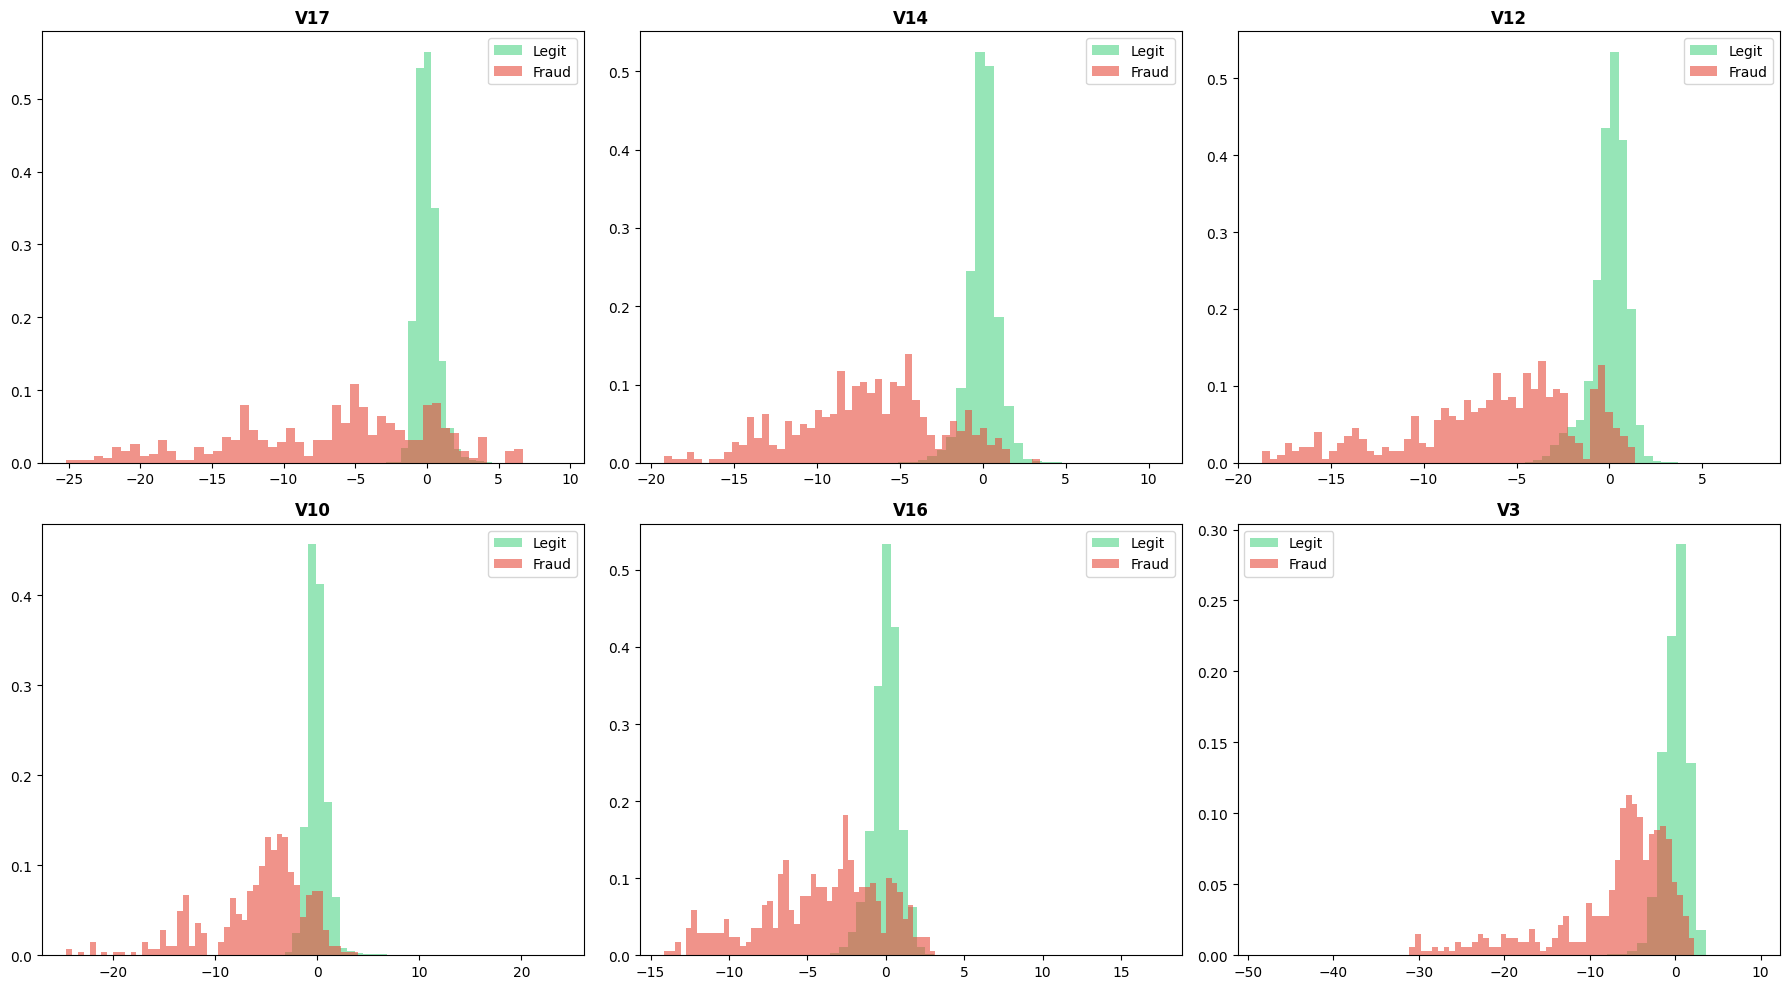

In [5]:
# Visualize top features
top=sig_df['Feature'].tolist()[:6]
fig,axes=plt.subplots(2,3,figsize=(18,10)); axes=axes.flatten()
for i,f in enumerate(top):
    axes[i].hist(legit[f],bins=50,alpha=0.5,color='#2ecc71',label='Legit',density=True)
    axes[i].hist(fraud[f],bins=50,alpha=0.6,color='#e74c3c',label='Fraud',density=True)
    axes[i].set_title(f,fontweight='bold'); axes[i].legend()
plt.tight_layout(); plt.show()

## Preprocessing

In [6]:
rs=RobustScaler()
df['Amount_s']=rs.fit_transform(df['Amount'].values.reshape(-1,1))
df['Time_s']=rs.fit_transform(df['Time'].values.reshape(-1,1))
X=df.drop(['Amount','Time','Class'],axis=1); y=df['Class']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f'Train: {X_train.shape[0]:,}, Test: {X_test.shape[0]:,}')

Train: 227,845, Test: 56,962


## Sampling Strategy Comparison

In [7]:
samplers={'No Sampling':None,'Undersampling':RandomUnderSampler(random_state=42),
          'SMOTE':SMOTE(random_state=42),'ADASYN':ADASYN(random_state=42)}
for name,s in samplers.items():
    Xr,yr=(X_train,y_train) if s is None else s.fit_resample(X_train,y_train)
    lr=LogisticRegression(max_iter=1000,random_state=42).fit(Xr,yr)
    yp=lr.predict(X_test)
    print(f'{name:20s}: F1={f1_score(y_test,yp):.4f}, Recall={recall_score(y_test,yp):.4f}')

No Sampling         : F1=0.7200, Recall=0.6429
Undersampling       : F1=0.0738, Recall=0.9184
SMOTE               : F1=0.1110, Recall=0.9184
ADASYN              : F1=0.0373, Recall=0.9184


## Supervised Models

In [8]:
sm=SMOTE(random_state=42); X_sm,y_sm=sm.fit_resample(X_train,y_train)
models={'LogReg(weighted)':LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42),
        'RF(SMOTE)':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1),
        'XGB(weighted)':XGBClassifier(n_estimators=100,scale_pos_weight=cd[0]/cd[1],random_state=42,eval_metric='logloss')}
results={}
for name,model in models.items():
    data=(X_sm,y_sm) if 'SMOTE' in name else (X_train,y_train)
    model.fit(*data)
    yp=model.predict(X_test); yprob=model.predict_proba(X_test)[:,1]
    results[name]={'Precision':precision_score(y_test,yp),'Recall':recall_score(y_test,yp),
        'F1':f1_score(y_test,yp),'AUC':roc_auc_score(y_test,yprob),'yp':yp,'yprob':yprob}
    print(f'{name}: Recall={results[name]["Recall"]:.4f}, F1={results[name]["F1"]:.4f}, AUC={results[name]["AUC"]:.4f}')

LogReg(weighted): Recall=0.9184, F1=0.1141, AUC=0.9720
RF(SMOTE): Recall=0.8163, F1=0.8466, AUC=0.9632
XGB(weighted): Recall=0.8367, F1=0.8586, AUC=0.9722


## Anomaly Detection

In [9]:
# Isolation Forest
iso=IsolationForest(n_estimators=100,contamination=0.00172,random_state=42,n_jobs=-1)
iso_pred=np.where(iso.fit_predict(X_test)==-1,1,0)
print(f'Isolation Forest: Precision={precision_score(y_test,iso_pred):.4f}, Recall={recall_score(y_test,iso_pred):.4f}, F1={f1_score(y_test,iso_pred):.4f}')

# LOF
lof=LocalOutlierFactor(n_neighbors=20,contamination=0.00172)
lof_pred=np.where(lof.fit_predict(X_test)==-1,1,0)
print(f'LOF: Precision={precision_score(y_test,lof_pred):.4f}, Recall={recall_score(y_test,lof_pred):.4f}, F1={f1_score(y_test,lof_pred):.4f}')

Isolation Forest: Precision=0.2959, Recall=0.2959, F1=0.2959
LOF: Precision=0.0204, Recall=0.0204, F1=0.0204


## Autoencoder

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, Model
X_normal=X_train[y_train==0]
sc=StandardScaler(); X_ae=sc.fit_transform(X_normal); X_te=sc.transform(X_test)
inp=tf.keras.Input(shape=(X_ae.shape[1],))
e=layers.Dense(14,activation='relu')(inp)
e=layers.Dense(7,activation='relu')(e)
d=layers.Dense(14,activation='relu')(e)
out=layers.Dense(X_ae.shape[1],activation='linear')(d)
ae=Model(inp,out); ae.compile(optimizer='adam',loss='mse')
ae.fit(X_ae,X_ae,epochs=30,batch_size=256,validation_split=0.1,verbose=0)
print('Autoencoder trained!')

Autoencoder trained!


In [11]:
pred=ae.predict(X_te,verbose=0)
err=np.mean(np.square(X_te-pred),axis=1)
# Find best threshold
ths=np.linspace(0,np.percentile(err,99),100)
f1s=[f1_score(y_test,(err>t).astype(int)) if (err>t).sum()>0 else 0 for t in ths]
best_t=ths[np.argmax(f1s)]
ae_pred=(err>best_t).astype(int)
print(f'Autoencoder: Precision={precision_score(y_test,ae_pred):.4f}, Recall={recall_score(y_test,ae_pred):.4f}, F1={f1_score(y_test,ae_pred):.4f}')

Autoencoder: Precision=0.1404, Recall=0.8163, F1=0.2395


## Model Comparison

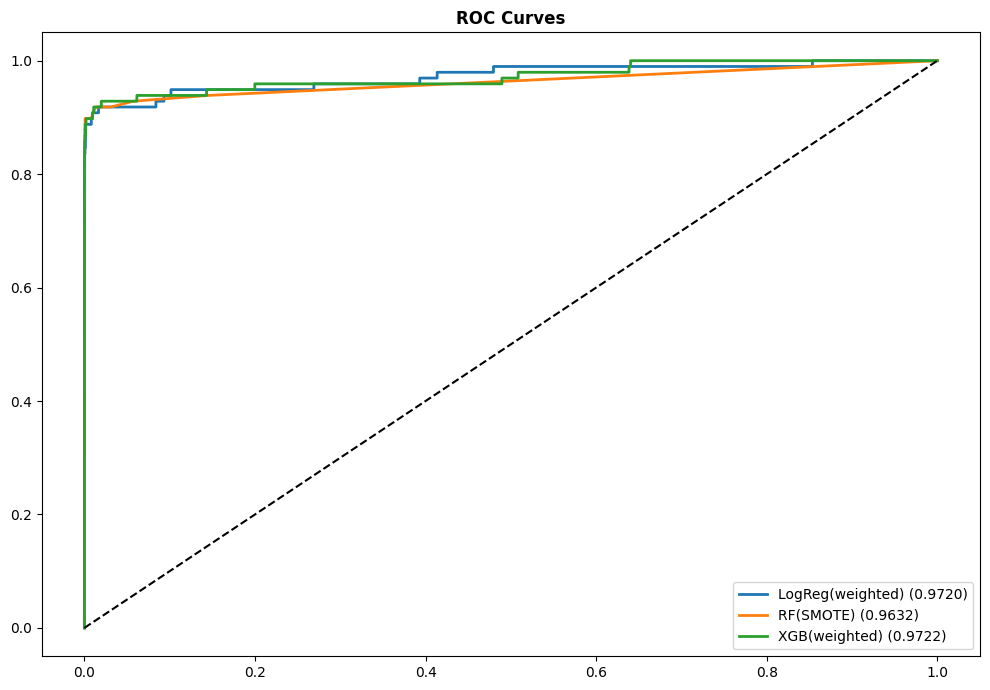

In [12]:
# ROC curves
fig,ax=plt.subplots(figsize=(10,7))
for name,r in results.items():
    fpr,tpr,_=roc_curve(y_test,r['yprob'])
    ax.plot(fpr,tpr,lw=2,label=f"{name} ({r['AUC']:.4f})")
ax.plot([0,1],[0,1],'k--'); ax.set_title('ROC Curves',fontweight='bold'); ax.legend()
plt.tight_layout(); plt.show()

In [13]:
# Full comparison
all_r={}
for n,r in results.items(): all_r[n]={k:v for k,v in r.items() if k not in['yp','yprob']}
all_r['Isolation Forest']={'Precision':precision_score(y_test,iso_pred),'Recall':recall_score(y_test,iso_pred),'F1':f1_score(y_test,iso_pred),'AUC':'-'}
all_r['LOF']={'Precision':precision_score(y_test,lof_pred),'Recall':recall_score(y_test,lof_pred),'F1':f1_score(y_test,lof_pred),'AUC':'-'}
all_r['Autoencoder']={'Precision':precision_score(y_test,ae_pred),'Recall':recall_score(y_test,ae_pred),'F1':f1_score(y_test,ae_pred),'AUC':'-'}
print(pd.DataFrame(all_r).T)

                 Precision    Recall        F1       AUC
LogReg(weighted)  0.060852  0.918367  0.114141  0.972032
RF(SMOTE)         0.879121  0.816327  0.846561  0.963199
XGB(weighted)      0.88172  0.836735  0.858639  0.972164
Isolation Forest  0.295918  0.295918  0.295918         -
LOF               0.020408  0.020408  0.020408         -
Autoencoder       0.140351  0.816327  0.239521         -


## Summary

In [14]:
print('7 models compared: 3 supervised + 2 anomaly detection + 1 autoencoder')
print('SMOTE best for supervised models. XGBoost with class weights works well natively.')
print('Autoencoder captures non-linear fraud patterns. Ensemble recommended for production.')

7 models compared: 3 supervised + 2 anomaly detection + 1 autoencoder
SMOTE best for supervised models. XGBoost with class weights works well natively.
Autoencoder captures non-linear fraud patterns. Ensemble recommended for production.
